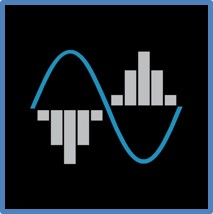
# **ANÁLISIS DE SEÑALES Y SISTEMAS (ASyS)**

## **TERCER PARCIAL**: CASO DE ESTUDIO 1


### **GRUPO DE TRABAJO:** *1*

### **INTEGRANTES:**
1.   Sharpe, Ariel
2.   Belmonte, Enzo
3.   González Falbo, Matias Fernando




### **MÓDULOS DE USO GENERAL EN PYTHON**


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from scipy.signal import firwin, butter, lfilter,  bessel, iirfilter, firwin
import IPython as IP
from scipy.io import wavfile
from random import random

### **TOOLBOX ASyS**

In [7]:
#Definición de la función IMPULSO UNITARIO APROXIMADO delta(t)
delta = lambda t,Ts: np.piecewise(t, (t>=0) & (t<Ts), [1/Ts,0])

#Definición de la función ESCALÓN UNITARIO u(t)
u = lambda t: np.piecewise(t, t>=0, [1,0])

#Definición de la función RAMPA UNITARIA rho(t)
rho = lambda t: t*u(t)

#Función ENERGIA
def ENERGIA(x, dt=1):
    '''
    x: signal
    dt: time-step used to define the signal x.
        Default value: dt = 1
    '''
    return np.sum(np.abs(x)**2)*dt

#Función POTENCIA
def POTENCIA(x, T0, dt=1):
    '''
    x: a period (ONLY ONE) of the signal
    T0: signal period
    dt: time-step used to define the signal x.
        Default value: dt = 1
    '''
    return 1/T0 * np.sum(np.abs(x)**2)*dt

#FUNCIÓN STF (SERIE DE FOURIER ANÁLISIS)
def STF(t, ft, N, T0):
    '''
    Calculates the Fourier Trigonomectric Series coefficients

    Parameters:
    t (ndarray):  time vector used to define ft
    ft (ndarray): signal to calculate the STF coefficients
    N (int):  number of coefficients (an & bn) to calculate
    T0 (float): signal period

    Returns:
    an (ndarray): an from FTS
    bn (ndarray): bn from FTS

    Example1:
    t = np.arange(-2, 2, 0.001)
    x = abs(t)
    [an, bn] = STF(t, x, 10, 4)

    Note:
    an[0] is the a0 value.
    bn[0] is always zero.
    '''

    w0 = 2*np.pi/T0
    dt = t[1] - t[0]

    index_1p = int(T0/dt)

    #if (len(t) < index_1p or len(ft) < index_1p):
    #    print(STF.__name__ + " - Error: t or ft shorter than 1 period")
    #    return

    t1p = t[: index_1p]
    ft1p = ft[: index_1p]

    a0 = 2/T0* sum(ft1p) * dt

    an= np.zeros(N+1);
    bn = np.zeros(N+1);
    for n in range(1, N+1):
        an[n] = 2/T0 * sum(ft1p*np.cos(n*w0*t1p)) * dt
        bn[n] = 2/T0 * sum(ft1p*np.sin(n*w0*t1p)) * dt

    an[0] = a0

    return [an,bn]

#FUNCIÓN ISTF (SERIE DE FOURIER SÍNTESIS)
def ISTF(t, an, bn, T0):
    '''
    Recreate a signal based on its TFS coefficients

    Receives:
    t (ndarray): time vector used to recreate the signal
    an (ndarray): an from FTS
    bn (ndarray): bn from FTS
    T0 (float): signal period

    Returns:
    ft1 (ndarray): synthesized signal

    Example:
    t = np.arange(-2, 2, 0.001)
    x = abs(t)
    [an, bn] = STF(t, x, 10, 4)
    tsyn = np.arange(-6, 6, 0.001)
    xsyn = ISTF(tsyn, an, bn, 4)
    '''

    w0 = 2*np.pi/T0;
    N = len(bn)
    ft1 = np.zeros(len(t))

    for n in range(1, N):
        ft1 = ft1 + an[n] * np.cos(w0*n*t) + bn[n] * np.sin(w0*n*t)

    ft1 = ft1.real
    ft1 = ft1 + an[0]/2

    return ft1

    #FUNCIÓN SEF (SERIE EXPONENCIAL DE FOURIER ANÁLISIS)
def SEF(t, ft, N, T0):
    '''
    Calculates the Fourier Exponential Series coefficients

    Parameters:
    t (ndarray):  time vector used to define ft
    ft (ndarray): signal to calculate the STF coefficients
    N (int):  number of positive frequency coefficients (cn) to calculate (including C0)
    T0 (float): signal period

    Returns:
    cn (ndarray): Cn from FES

    Example1:
    t = np.arange(-2, 2, 0.001)
    x = abs(t)
    Cn = STF(t, x, 10, 4)
    '''

    w0 = 2*np.pi/T0
    dt = t[1] - t[0]

    index_1p = int(T0/dt)

    #if (len(t) < index_1p or len(ft) < index_1p):
    #    print(STF.__name__ + " - Error: t or ft shorter than 1 period")
    #    return

    t1p = t[: index_1p]
    ft1p = ft[: index_1p]

    c0 = 1/T0* sum(ft1p) * dt

    cn= np.zeros(2*N-1,dtype=np.complex_);
    for n in range(-(N-1), N):
        cn[n+N-1] = 1/T0 * sum(ft1p*np.exp(-1j*n*w0*t1p)) * dt

    cn[N-1] = c0

    return cn

#FUNCIÓN ISEF (SERIE EXPONENCIAL DE FOURIER SÍNTESIS)
def ISEF(t, cn, T0):
    '''
    Recreate a signal based on its SEF coefficients

    Receives:
    t (ndarray): time vector used to recreate the signal
    cn (ndarray): an from SEF
    T0 (float): signal period

    Returns:
    ft1 (ndarray): synthesized signal

    Example:
    t = np.arange(-2, 2, 0.001)
    x = abs(t)
    cn = SEF(t, x, 10, 4)
    tsyn = np.arange(-6, 6, 0.001)
    xsyn = ISEF(tsyn, cn, 4)
    '''

    w0 = 2*np.pi/T0;
    N = int(len(cn)/2)+1
    ft1 = np.zeros(len(t),dtype=np.complex_)

    for n in range(-(N-1), N):
        ft1 = ft1 + cn[n+N-1] * np.exp(1j*w0*n*t)

    ft1 = ft1.real

    return ft1

### **FUNCIÓN SIMPLIFICADA FFT** (útil para graficar)

In [8]:
def fft_simple(ft, n, T0, f_hasta=0):
  lim = int(n//2 + n*f_hasta*T0) if f_hasta != 0 else n
  xf = sp.fft.fftshift(sp.fft.fftfreq(n, T0))[int(n//2):lim]
  fft=sp.fft.fftshift(np.abs(sp.fft.fft(ft)))[int(n//2):lim]
  return xf, fft

## **CARGA DE ARCHIVO DE AUDIO**


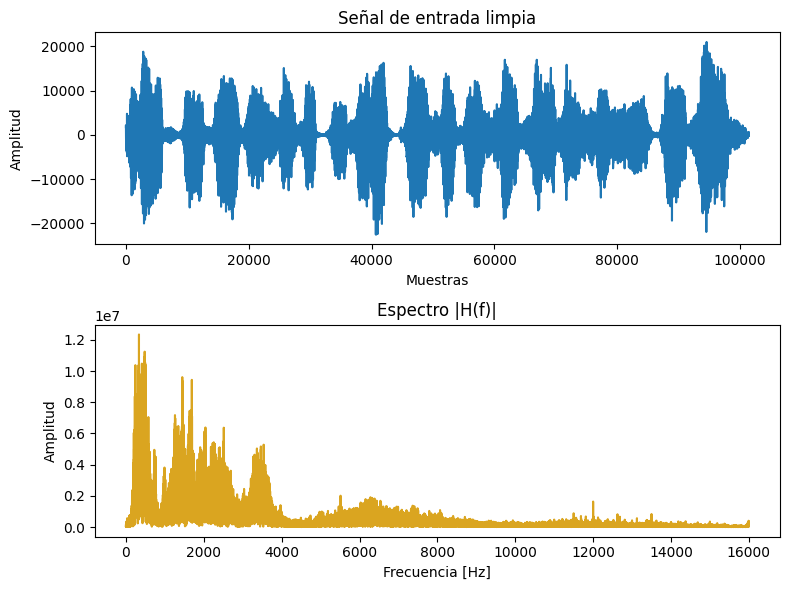

In [9]:
#Carga de Datos
Fs, Datos_WAV = wavfile.read('Bienvenida.wav')
Datos_WAV = Datos_WAV.astype(np.float64)
n_muestras = len(Datos_WAV)
t = np.arange(0, n_muestras)
t_e, fft_entrada = fft_simple(Datos_WAV, n_muestras, 1/Fs)
fft_entrada_completa = sp.fft.fft(Datos_WAV)

#Visualización
plt.figure(figsize=[8,6])
plt.subplot(211)
plt.plot(Datos_WAV)
plt.title("Señal de entrada limpia")
plt.xlabel('Muestras')
plt.ylabel('Amplitud')
plt.subplot(212)
plt.plot(t_e, fft_entrada, color='goldenrod')
plt.title("Espectro |H(f)|")
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Amplitud')
plt.tight_layout()
plt.show()
#Sumo ruido 500 Hz para acomodar la FFT
t_ruido = np.linspace(0, (n_muestras/Fs), n_muestras, endpoint=False)
f_delta = delta(t_ruido, 1/Fs)
#ruido = (np.sin(2*np.pi*500*t_ruido)*500).astype(int)
#Datos_WAV += ruido
#Reproducción
IP.display.Audio(Datos_WAV, rate=Fs, autoplay=False)



---

## **SIMULACIÓN DE RUIDO**

/usr/local/lib/python3.10/dist-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.10/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/usr/local/lib/python3.10/dist-packages/IPython/lib/display.py:159: ComplexWarning: Casting complex values to real discards the imaginary part
  data = np.array(data, dtype=float)


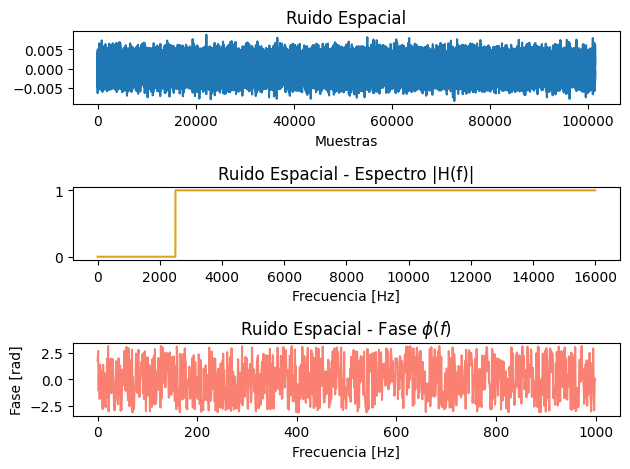

In [10]:
## Generamos RUIDO en BANDA 2500-16KHz con H(n)
# Hacemos el H(n) y fase de nuestra señal esperada, y antitransformamos

#t = np.linspace(0, (n_muestras/Fs), n_muestras, endpoint=False)
#f_delta = delta(t, 1/Fs)
#f_sin = (np.sin(2*np.pi*500*t))

f_inicio = 2500
n1 = int((f_inicio / Fs) * n_muestras)
fase = np.random.uniform(-np.pi, np.pi, size=(n_muestras))
#generamos H(n) para sp.ifft
H_rbg = np.concatenate((np.zeros(n1), np.ones(n_muestras - n1*2), np.zeros(n1))) * np.exp(1j * fase)
f_rbg = sp.fft.ifft(H_rbg)

#Transformamos de nuevo para ver qué salió y comparar con el H(n) propuesto
t_h, fft_h = fft_simple(f_rbg, n_muestras, 1/Fs)
plt.subplot(311)
plt.title("Ruido Espacial")
plt.plot(f_rbg)
plt.xlabel('Muestras')

plt.subplot(312)
plt.title("Ruido Espacial - Espectro |H(f)|")
plt.plot(t_h, fft_h, color='goldenrod')
plt.xlabel('Frecuencia [Hz]')

plt.subplot(313)
plt.title("Ruido Espacial - Fase $\phi(f)$")
plt.plot(fase[1000:2000], color='salmon')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Fase [rad]')
plt.tight_layout()

IP.display.Audio(f_rbg, rate=Fs, autoplay=False)

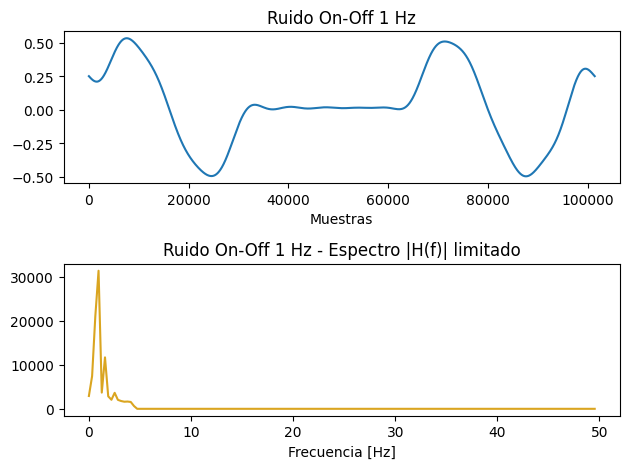

In [11]:
## Ahora ruido 1Hz
n_corte = 30000
n_sigue = 65000
f_1hz = np.sin(2*np.pi*t/Fs) * np.concatenate((np.ones(n_corte), np.zeros(n_sigue - n_corte), np.ones(n_muestras - n_sigue)))
f_inicio = 0
f_fin = 5
n11 = int((f_inicio / Fs) * n_muestras)
n12 = int(((f_fin - f_inicio) / Fs) * n_muestras)
#generamos H(n) para cortar el ruido
fft_1hz = sp.fft.fft(f_1hz)
H_corte1 = np.concatenate((np.zeros(n11), np.ones(n12), np.zeros(n_muestras - n11 - n12)))
f_1_i = sp.fft.ifft(fft_1hz * H_corte1)
plt.subplot(211)
plt.title("Ruido On-Off 1 Hz")
plt.plot(f_1_i)
plt.xlabel('Muestras')
t_1, fft_1 = fft_simple(f_1_i, n_muestras, 1/Fs, 50)
plt.subplot(212)
plt.title("Ruido On-Off 1 Hz - Espectro |H(f)| limitado")
plt.plot(t_1, fft_1, color='goldenrod')
plt.xlabel('Frecuencia [Hz]')
plt.tight_layout()
IP.display.Audio(f_1_i, rate=Fs, autoplay=False)

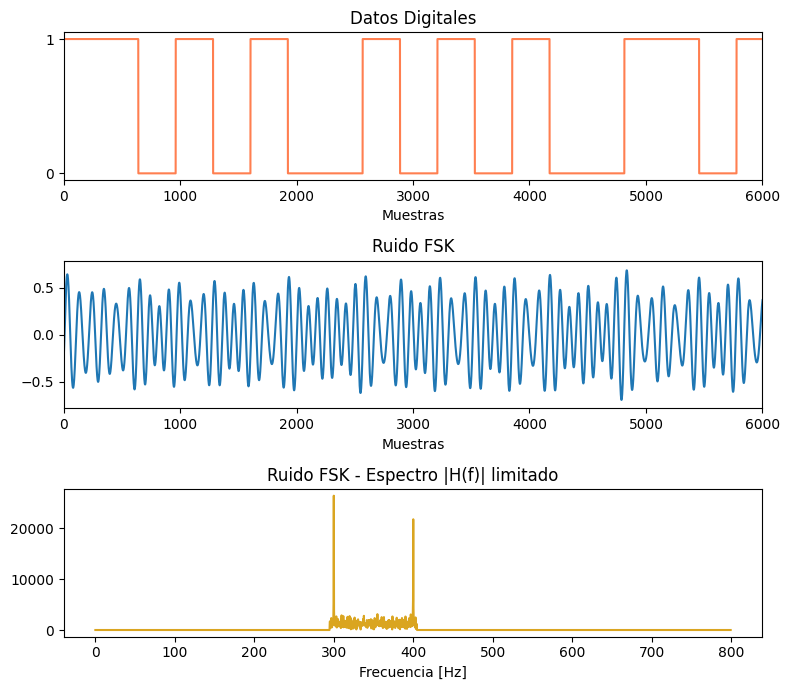

In [12]:
## Ruido en banda 300-400 Hz - Probamos FSK
datos_digital = np.random.randint(0, 2, n_muestras//320)
f_300hz = np.sin(2*np.pi*300*t/Fs)
f_400hz = np.sin(2*np.pi*400*t/Fs - 0.25)
f_dig = lambda x: datos_digital[(n_muestras//320 * x/n_muestras).astype(int)]
plt.figure(figsize=[8,7])
plt.subplot(311)
plt.title("Datos Digitales")
plt.xlabel('Muestras')
plt.plot(t, f_dig(t), color='coral')
plt.xlim(0, 6000)
plt.yticks([0, 1])
f_ruido_fsk = np.ones(n_muestras) * (f_300hz * f_dig(t) + f_400hz * (1 - f_dig(t)))
f_inicio = 295
f_fin = 405
n1 = int((f_inicio / Fs) * n_muestras)
n2 = int(((f_fin - f_inicio) / Fs) * n_muestras)
#generamos H(n) para cortar el ruido
fft_fsk = sp.fft.fft(f_ruido_fsk)
H_corte = np.concatenate((np.zeros(n1), np.ones(n2), np.zeros(n_muestras - n1 - n2)))
f_fsk = sp.fft.ifft(fft_fsk * H_corte)
#Nos queda un ruido digital entre 300 y 400 Hz
plt.subplot(312)
plt.title("Ruido FSK")
plt.xlabel('Muestras')
plt.plot(t, f_fsk)
plt.xlim(0, 6000)
tfsk, fftfsk = fft_simple(f_fsk, n_muestras, 1/Fs, 800)
plt.subplot(313)
plt.title("Ruido FSK - Espectro |H(f)| limitado")
plt.xlabel('Frecuencia [Hz]')
plt.plot(tfsk, fftfsk, color='goldenrod')
plt.tight_layout()
plt.show()

IP.display.Audio(f_fsk, rate=Fs, autoplay=False)

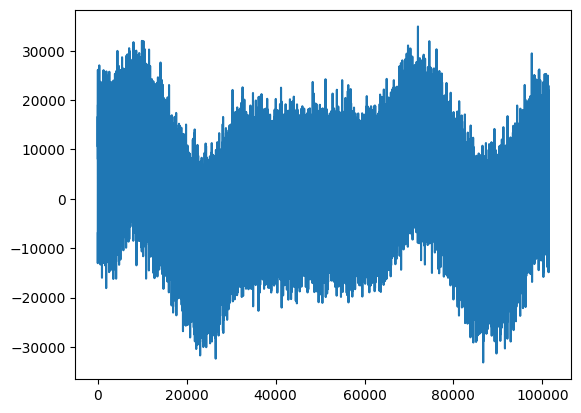

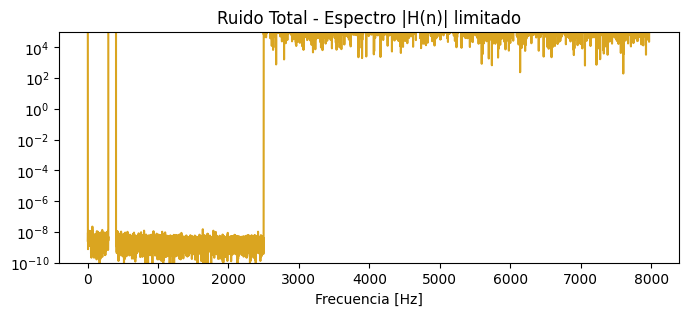

In [13]:
## Sumando...

ruido_total = np.real((f_rbg * 100 + f_1_i + f_fsk)*20000)
plt.plot(ruido_total)
plt.show()
t_tot, fft_tot = fft_simple(ruido_total, n_muestras, 1/Fs, 8000)
plt.figure(figsize=[8,3])
tot = plt.subplot(111)
plt.title("Ruido Total - Espectro |H(n)| limitado")
plt.xlabel('Frecuencia [Hz]')
tot.plot(t_tot, fft_tot, color='goldenrod')
tot.set_yscale('log')
plt.ylim(1e-10, 1e5)
plt.show()

IP.display.Audio(ruido_total, rate=Fs, autoplay=False)


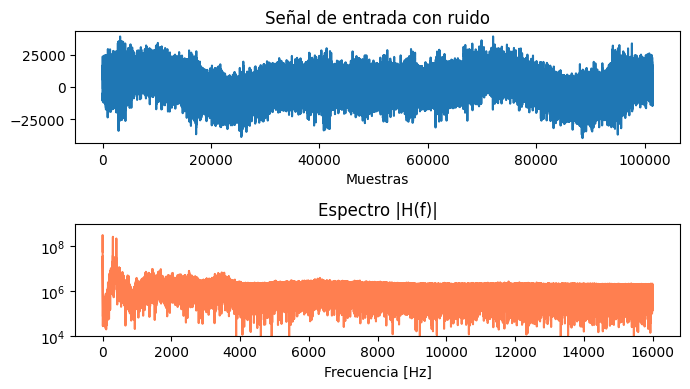

In [14]:
## Agregamos el ruido a nuestro audio limpio
Datos_ruido = Datos_WAV + ruido_total
tr, fftr = fft_simple(Datos_ruido, n_muestras, 1/Fs)

plt.figure(figsize=[7,4])
plt.subplot(211)
plt.plot(t, Datos_ruido)
plt.title("Señal de entrada con ruido")
plt.xlabel('Muestras')
esp = plt.subplot(212)
esp.plot(tr, fftr, color='coral')
esp.set_yscale('log')
plt.ylim(1e4, 1e9)
plt.title("Espectro |H(f)|")
plt.xlabel('Frecuencia [Hz]')
plt.tight_layout()
plt.savefig('ruido.png', dpi=300)
plt.show()
IP.display.Audio(Datos_ruido, rate=Fs, autoplay=False)



---



## **DISEÑO y APLICACIÓN DE FILTROS**



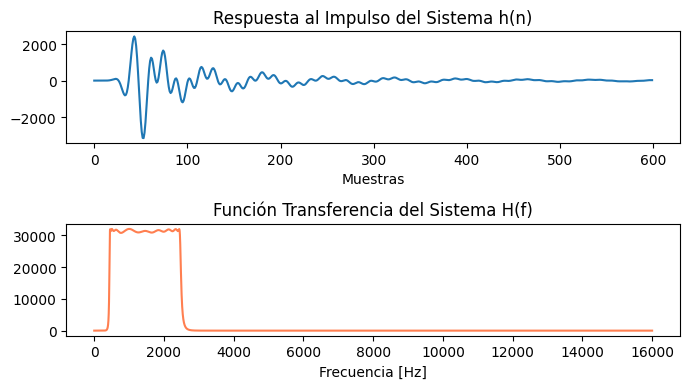

In [15]:
## Generamos Filtros para quitar el ruido
#  PASA BAJO IIR
bl, al = iirfilter(N=15, Wn=2450, btype='lowpass', ftype='cheby1', fs=32000, rp=0.175, rs=60)
#  PASA ALTO IIR
bh, ah = iirfilter(N=10, Wn=450, btype='highpass', ftype='cheby1', fs=32000, rp=0.175, rs=60)
#  Visualizamos el H(n) transformando la RESPUESTA AL IMPULSO
f_delta = delta(t, 1/Fs)
h_lp = lfilter(bl, al, f_delta)
h_lphp = lfilter(bh, ah, h_lp)
t_h, fft_h = fft_simple(h_lphp, n_muestras, 1/Fs)
plt.figure(figsize=[7,4])
plt.subplot(211)
plt.plot(t[:600], h_lphp[:600])
plt.title("Respuesta al Impulso del Sistema h(n)")
plt.xlabel('Muestras')
plt.subplot(212)
plt.plot(t_h, fft_h, color='coral')
plt.title("Función Transferencia del Sistema H(f)")
plt.xlabel('Frecuencia [Hz]')
plt.tight_layout()
plt.show()


In [16]:
print("Bl:")
print(bl)
print("Al:")
print(al)


Bl:
[1.18532971e-13 1.77799457e-12 1.24459620e-11 5.39325020e-11
 1.61797506e-10 3.55954513e-10 5.93257522e-10 7.62759671e-10
 7.62759671e-10 5.93257522e-10 3.55954513e-10 1.61797506e-10
 5.39325020e-11 1.24459620e-11 1.77799457e-12 1.18532971e-13]
Al:
[ 1.00000000e+00 -1.34557180e+01  8.52841166e+01 -3.37688889e+02
  9.34018648e+02 -1.91128411e+03  2.98881321e+03 -3.63666242e+03
  3.47106905e+03 -2.59868103e+03  1.51353783e+03 -6.73445938e+02
  2.21590988e+02 -5.09027941e+01  7.29971658e+00 -4.92657561e-01]


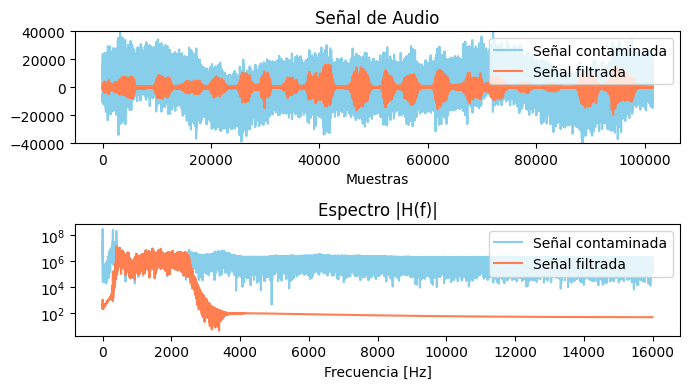

In [17]:
## Ahora filtramos
audio_lp = lfilter(bl, al, Datos_ruido)
audio_lphp = lfilter(bh, ah, audio_lp)
t_fil, fft_fil = fft_simple(audio_lphp, n_muestras, 1/Fs)

plt.figure(figsize=[7,4])
plt.subplot(211)
plt.plot(t, Datos_ruido, color='skyblue')
plt.title("Señal de Audio")
plt.xlabel('Muestras')
plt.plot(t, audio_lphp, color='coral')
plt.legend(['Señal contaminada', 'Señal filtrada'], loc=1)
plt.ylim(-40000, 40000)
esp = plt.subplot(212)
esp.plot(tr, fftr, color='skyblue')
esp.plot(t_fil, fft_fil, color='coral')
esp.set_yscale('log')
plt.title("Espectro |H(f)|")
plt.xlabel('Frecuencia [Hz]')
plt.legend(['Señal contaminada', 'Señal filtrada'], loc=1)
plt.tight_layout()

plt.show()
IP.display.Audio(audio_lphp, rate=Fs, autoplay=False)

## **ANEXO**

Pruebas

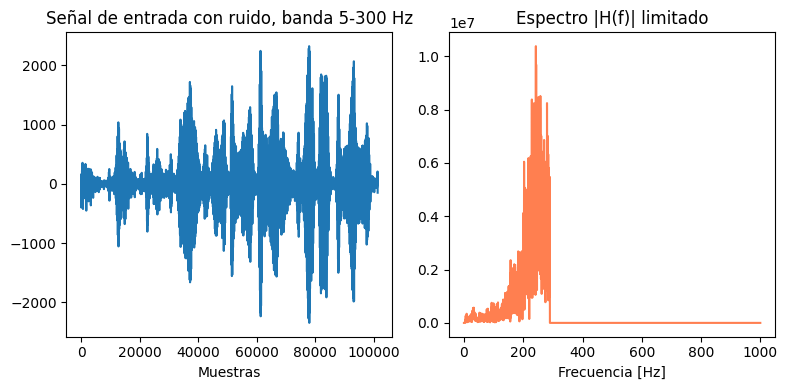

In [18]:
f_inicio2 = 5
f_fin2 = 290
n21 = int((f_inicio2 / Fs) * n_muestras)
n22 = int(((f_fin2 - f_inicio2) / Fs) * n_muestras)
fft_aud = sp.fft.fft(Datos_ruido)
H_corte2 = np.concatenate((np.zeros(n21), np.ones(n22), np.zeros(n_muestras - n21 - n22)))
aud_300 = sp.fft.ifft(fft_aud * H_corte2)
ta, ffta = fft_simple(aud_300, n_muestras, 1/Fs, 1000)
plt.figure(figsize=[8,4])
plt.subplot(121)
plt.plot(aud_300)
plt.title("Señal de entrada con ruido, banda 5-300 Hz")
plt.xlabel('Muestras')
plt.subplot(122)
plt.plot(ta, ffta, color="coral")
plt.title("Espectro |H(f)| limitado")
plt.xlabel('Frecuencia [Hz]')
plt.tight_layout()
plt.show()

IP.display.Audio(aud_300, rate=Fs, autoplay=False)